In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
import numpy as np

In [4]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Tải dữ liệu MNIST

In [5]:
digits = datasets.load_digits()
n_samples = len(digits.images)
print('The number of samples: ', n_samples)
print('shape of digit samples:', digits.images.shape)

The number of samples:  1797
shape of digit samples: (1797, 8, 8)


## Hiển thị các ảnh chữ số mẫu

In [6]:
def display_digits(X, Y):
    fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(10,10))
    fig.suptitle("Display randomly images of the training data set")
    for i in range(5):
        for j in range(5):
            ind = np.random.randint(X.shape[0])
            tmp = X[ind]
            ax[i,j].set_title("Label: {}".format(Y[ind]))
            ax[i,j].imshow(tmp, cmap='gray_r')
            plt.setp(ax[i,j].get_xticklabels(), visible=False)
            plt.setp(ax[i,j].get_yticklabels(),visible=False)
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

## Tách dữ liệu huấn luyện + kiểm tra

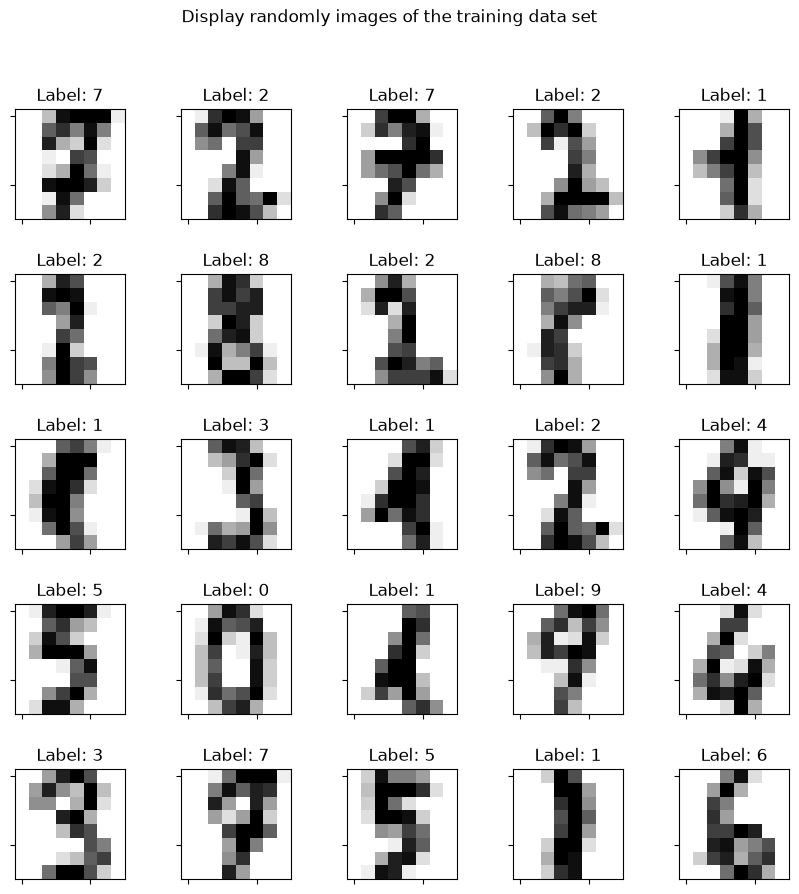

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    digits.images,
    digits.target,
    test_size = 0.2,
    random_state=200,
    shuffle=False
)
display_digits(X_train, y_train)

## Trực quan hóa tập chữ số PCA

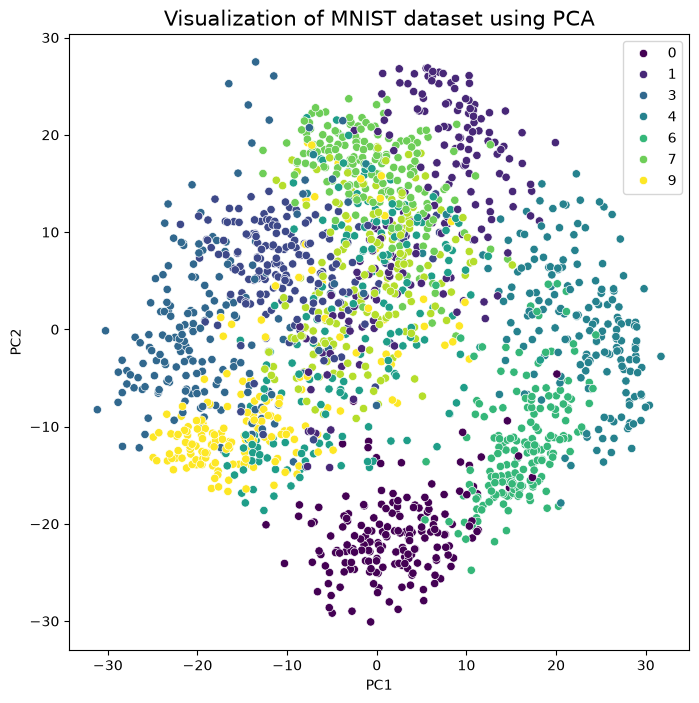

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data_pca = pca.fit_transform(digits.data)

plt.figure(figsize=(8, 8))
_ = sns.scatterplot(x=reduced_data_pca[:, 0],
                    y=reduced_data_pca[:, 1],
                    hue=digits.target,
                    palette='viridis')

_= plt.xlabel('PC1')
_= plt.ylabel('PC2')
_= plt.title('Visualization of MNIST dataset using PCA', {'fontsize': 15})

### Làm phẳng hình ảnh

In [11]:
# Flatten the images
X_train = X_train.reshape((len(X_train), -1))
X_test = X_test.reshape((len(X_test), -1))

# Create a classifier
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(penalty='l2',
                         fit_intercept=True,
                         random_state=2021,
                         solver='lbfgs',
                         max_iter=100,
                         verbose=1,
                         n_jobs=5)

# Learn the digits on the train subset
clf.fit(X_train, y_train)
predicted = clf.predict(X_test)

c:\Users\Dat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Dat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=5', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Dat\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERAT

### Hiển thị kết qua dự đoán hình ảnh minh họa

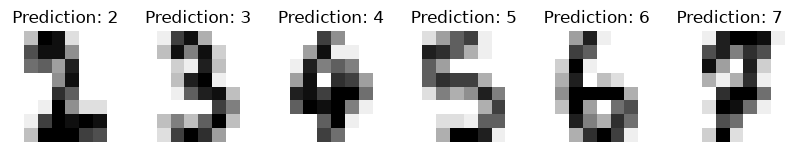

In [13]:
_, axes = plt.subplots(nrows=1, ncols=6, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Prediction: {prediction}')

### Đánh giá mô hình (Classification Report & Confusion Matrix)


Classification report fpr classifier LogisticRegression(n_jobs=5, penalty='l2', random_state=2021, verbose=1):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        35
           1       0.79      0.83      0.81        36
           2       1.00      1.00      1.00        35
           3       0.93      0.76      0.84        37
           4       0.94      0.92      0.93        37
           5       0.90      0.95      0.92        37
           6       0.97      0.97      0.97        37
           7       0.97      0.94      0.96        36
           8       0.78      0.85      0.81        33
           9       0.80      0.89      0.85        37

    accuracy                           0.91       360
   macro avg       0.91      0.91      0.91       360
weighted avg       0.91      0.91      0.91       360




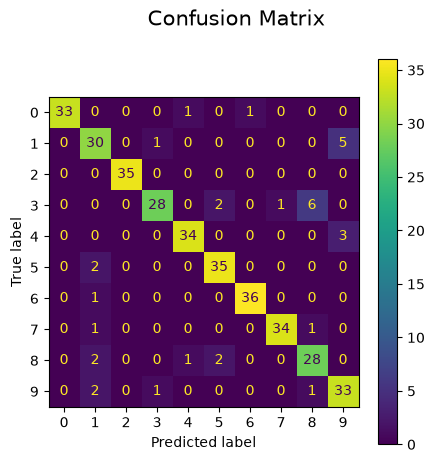

In [17]:
# Show classification report
print(f"Classification report fpr classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")

# Plot confusion matrix
plt.figure(figsize=(5, 5))
ax = plt.gca()
disp = metrics.ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, ax=ax
)
_= disp.figure_.suptitle("Confusion Matrix", fontsize=15)